In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

## Data Exploration

In [24]:
raw_f20 = pd.read_csv('features_nogabor_iou20.csv')
raw_f30 = pd.read_csv('features_nogabor_iou30.csv')
raw_f40 = pd.read_csv('features_nogabor_iou40.csv')
raw_f50 = pd.read_csv('features_nogabor_iou50.csv')

In [3]:
raw_f20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2990 entries, 0 to 2989
Columns: 382 entries, image_name to adversarial
dtypes: bool(1), float64(187), int64(193), object(1)
memory usage: 8.7+ MB


In [9]:
raw_f20.columns.tolist()

['image_name',
 'region_id',
 'area',
 'rgb_R_bin0',
 'rgb_R_bin1',
 'rgb_R_bin2',
 'rgb_R_bin3',
 'rgb_R_bin4',
 'rgb_R_bin5',
 'rgb_R_bin6',
 'rgb_R_bin7',
 'rgb_R_bin8',
 'rgb_R_bin9',
 'rgb_R_bin10',
 'rgb_R_bin11',
 'rgb_R_bin12',
 'rgb_R_bin13',
 'rgb_R_bin14',
 'rgb_R_bin15',
 'rgb_R_bin16',
 'rgb_R_bin17',
 'rgb_R_bin18',
 'rgb_R_bin19',
 'rgb_R_bin20',
 'rgb_R_bin21',
 'rgb_R_bin22',
 'rgb_R_bin23',
 'rgb_R_bin24',
 'rgb_R_bin25',
 'rgb_R_bin26',
 'rgb_R_bin27',
 'rgb_R_bin28',
 'rgb_R_bin29',
 'rgb_R_bin30',
 'rgb_R_bin31',
 'rgb_G_bin0',
 'rgb_G_bin1',
 'rgb_G_bin2',
 'rgb_G_bin3',
 'rgb_G_bin4',
 'rgb_G_bin5',
 'rgb_G_bin6',
 'rgb_G_bin7',
 'rgb_G_bin8',
 'rgb_G_bin9',
 'rgb_G_bin10',
 'rgb_G_bin11',
 'rgb_G_bin12',
 'rgb_G_bin13',
 'rgb_G_bin14',
 'rgb_G_bin15',
 'rgb_G_bin16',
 'rgb_G_bin17',
 'rgb_G_bin18',
 'rgb_G_bin19',
 'rgb_G_bin20',
 'rgb_G_bin21',
 'rgb_G_bin22',
 'rgb_G_bin23',
 'rgb_G_bin24',
 'rgb_G_bin25',
 'rgb_G_bin26',
 'rgb_G_bin27',
 'rgb_G_bin28',
 'rgb_

In [25]:
raw_f20["adversarial"].value_counts()

adversarial
False    2281
True      709
Name: count, dtype: int64

In [5]:
raw_f30["adversarial"].value_counts()

adversarial
False    2309
True      681
Name: count, dtype: int64

In [6]:
raw_f40["adversarial"].value_counts()

adversarial
False    2340
True      650
Name: count, dtype: int64

In [7]:
raw_f50["adversarial"].value_counts()

adversarial
False    2384
True      606
Name: count, dtype: int64

In [14]:
raw_f20.isna().sum().sum()

np.int64(0)

In [15]:
raw_f30.isna().sum().sum()

np.int64(0)

In [16]:
raw_f40.isna().sum().sum()

np.int64(0)

In [17]:
raw_f50.isna().sum().sum()

np.int64(0)

### Pearson Correlation

area                           0.188054
rgb_R_bin0                     0.060664
rgb_R_bin1                     0.089583
rgb_R_bin2                     0.102296
rgb_R_bin3                     0.102188
rgb_R_bin4                     0.097655
rgb_R_bin5                     0.109959
rgb_R_bin6                     0.119985
rgb_R_bin7                     0.107467
rgb_R_bin8                     0.101008
rgb_R_bin9                     0.106539
rgb_R_bin10                    0.106419
rgb_R_bin11                    0.105177
rgb_R_bin12                    0.102316
rgb_R_bin13                    0.108355
rgb_R_bin14                    0.114857
rgb_R_bin15                    0.120675
rgb_R_bin16                    0.122820
rgb_R_bin17                    0.125154
rgb_R_bin18                    0.126487
rgb_R_bin19                    0.129646
rgb_R_bin20                    0.140190
rgb_R_bin21                    0.160248
rgb_R_bin22                    0.177356
rgb_R_bin23                    0.191234


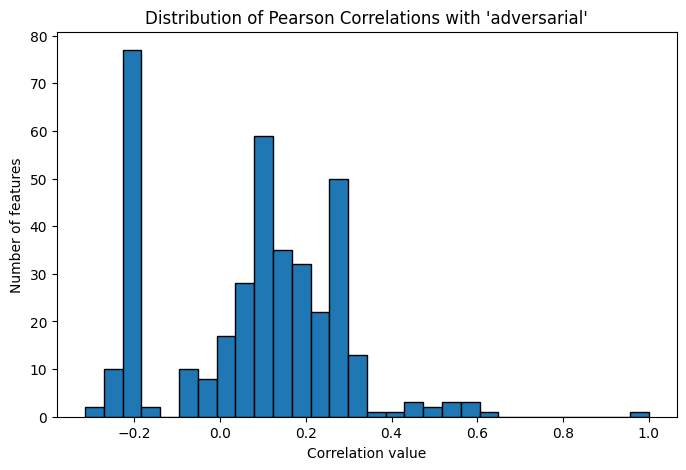

In [28]:
raw_f20["adversarial"] = raw_f20["adversarial"].astype(int)

# Drop "image_name" and "region_id" (they're not features)
numeric_df = raw_f20.drop(columns=["image_name", "region_id"], errors="ignore")
correlations = numeric_df.corrwith(raw_f20["adversarial"], method="pearson")
correlations = correlations.dropna()
plt.figure(figsize=(8, 5))
plt.hist(correlations, bins=30, edgecolor="black")
plt.title("Distribution of Pearson Correlations with 'adversarial'")
plt.xlabel("Correlation value")
plt.ylabel("Number of features")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(correlations)

area                           0.152480
rgb_R_bin0                     0.054601
rgb_R_bin1                     0.040284
rgb_R_bin2                     0.054696
rgb_R_bin3                     0.060211
rgb_R_bin4                     0.058614
rgb_R_bin5                     0.070027
rgb_R_bin6                     0.079762
rgb_R_bin7                     0.074185
rgb_R_bin8                     0.070942
rgb_R_bin9                     0.075932
rgb_R_bin10                    0.078515
rgb_R_bin11                    0.078088
rgb_R_bin12                    0.074925
rgb_R_bin13                    0.080632
rgb_R_bin14                    0.088776
rgb_R_bin15                    0.095584
rgb_R_bin16                    0.100238
rgb_R_bin17                    0.104421
rgb_R_bin18                    0.106784
rgb_R_bin19                    0.110435
rgb_R_bin20                    0.121326
rgb_R_bin21                    0.140016
rgb_R_bin22                    0.157363
rgb_R_bin23                    0.172994


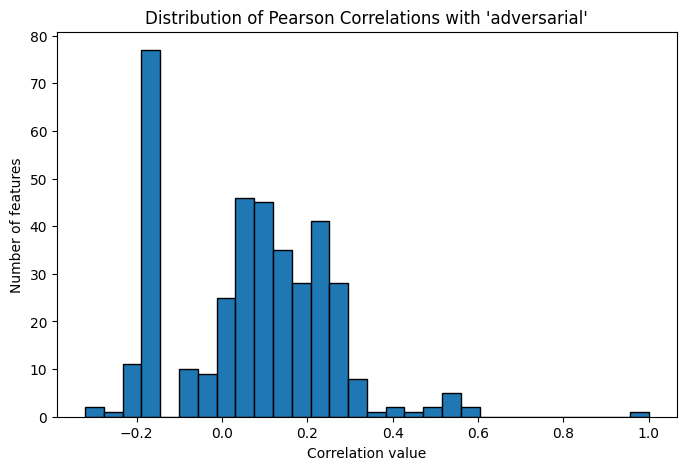

In [29]:
raw_f30["adversarial"] = raw_f30["adversarial"].astype(int)

# Drop "image_name" and "region_id" (they're not features)
numeric_df = raw_f30.drop(columns=["image_name", "region_id"], errors="ignore")
correlations = numeric_df.corrwith(raw_f30["adversarial"], method="pearson")
correlations = correlations.dropna()
plt.figure(figsize=(8, 5))
plt.hist(correlations, bins=30, edgecolor="black")
plt.title("Distribution of Pearson Correlations with 'adversarial'")
plt.xlabel("Correlation value")
plt.ylabel("Number of features")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(correlations)

area                           0.136506
rgb_R_bin0                     0.056581
rgb_R_bin1                     0.037183
rgb_R_bin2                     0.050964
rgb_R_bin3                     0.057039
rgb_R_bin4                     0.055850
rgb_R_bin5                     0.064982
rgb_R_bin6                     0.073877
rgb_R_bin7                     0.069322
rgb_R_bin8                     0.066413
rgb_R_bin9                     0.069987
rgb_R_bin10                    0.071380
rgb_R_bin11                    0.069923
rgb_R_bin12                    0.065124
rgb_R_bin13                    0.069289
rgb_R_bin14                    0.075988
rgb_R_bin15                    0.082789
rgb_R_bin16                    0.087562
rgb_R_bin17                    0.091431
rgb_R_bin18                    0.093475
rgb_R_bin19                    0.096274
rgb_R_bin20                    0.105000
rgb_R_bin21                    0.121402
rgb_R_bin22                    0.136498
rgb_R_bin23                    0.149179


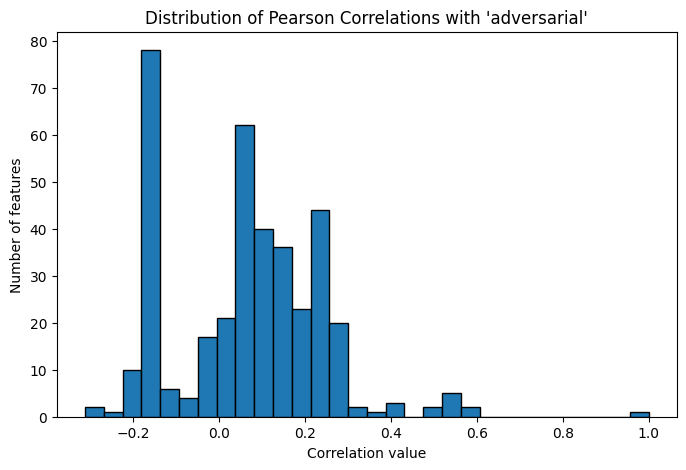

In [32]:
raw_f40["adversarial"] = raw_f40["adversarial"].astype(int)

# Drop "image_name" and "region_id" (they're not features)
numeric_df = raw_f40.drop(columns=["image_name", "region_id"], errors="ignore")
correlations = numeric_df.corrwith(raw_f40["adversarial"], method="pearson")
correlations = correlations.dropna()
plt.figure(figsize=(8, 5))
plt.hist(correlations, bins=30, edgecolor="black")
plt.title("Distribution of Pearson Correlations with 'adversarial'")
plt.xlabel("Correlation value")
plt.ylabel("Number of features")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(correlations)

area                           0.123599
rgb_R_bin0                     0.041128
rgb_R_bin1                     0.018209
rgb_R_bin2                     0.031586
rgb_R_bin3                     0.039845
rgb_R_bin4                     0.042090
rgb_R_bin5                     0.051654
rgb_R_bin6                     0.060580
rgb_R_bin7                     0.058141
rgb_R_bin8                     0.056778
rgb_R_bin9                     0.061732
rgb_R_bin10                    0.063500
rgb_R_bin11                    0.063016
rgb_R_bin12                    0.059169
rgb_R_bin13                    0.063306
rgb_R_bin14                    0.069967
rgb_R_bin15                    0.076728
rgb_R_bin16                    0.081571
rgb_R_bin17                    0.085615
rgb_R_bin18                    0.087598
rgb_R_bin19                    0.089307
rgb_R_bin20                    0.097186
rgb_R_bin21                    0.111019
rgb_R_bin22                    0.123397
rgb_R_bin23                    0.134784


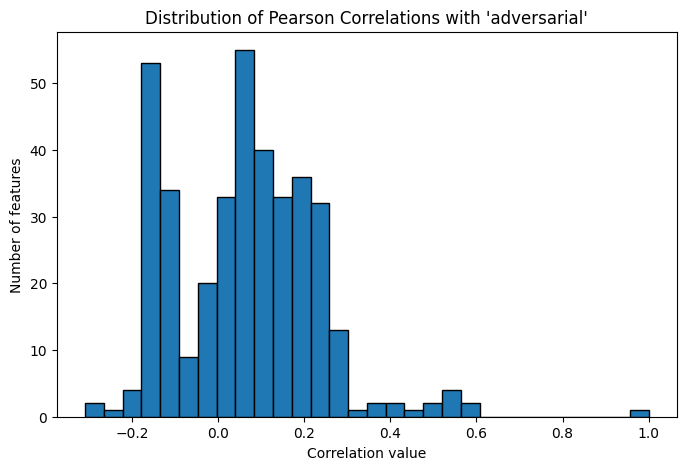

In [33]:
raw_f50["adversarial"] = raw_f50["adversarial"].astype(int)

# Drop "image_name" and "region_id" (they're not features)
numeric_df = raw_f50.drop(columns=["image_name", "region_id"], errors="ignore")
correlations = numeric_df.corrwith(raw_f50["adversarial"], method="pearson")
correlations = correlations.dropna()
plt.figure(figsize=(8, 5))
plt.hist(correlations, bins=30, edgecolor="black")
plt.title("Distribution of Pearson Correlations with 'adversarial'")
plt.xlabel("Correlation value")
plt.ylabel("Number of features")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(correlations)

## Data Preprocessing

### Splitting

In [31]:
from sklearn.model_selection import train_test_split

In [34]:
X_f20 = raw_f20.drop(columns=["image_name", "region_id", "adversarial"], errors="ignore")
X_f30 = raw_f30.drop(columns=["image_name", "region_id", "adversarial"], errors="ignore")
X_f40 = raw_f40.drop(columns=["image_name", "region_id", "adversarial"], errors="ignore")
X_f50 = raw_f50.drop(columns=["image_name", "region_id", "adversarial"], errors="ignore")

Y_f20 = raw_f20['adversarial']
Y_f30 = raw_f30['adversarial']
Y_f40 = raw_f40['adversarial']
Y_f50 = raw_f50['adversarial']

In [35]:
X_f20.head()

,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,rgb_R_bin7,rgb_R_bin8,rgb_R_bin9,rgb_R_bin10,rgb_R_bin11,rgb_R_bin12,rgb_R_bin13,rgb_R_bin14,rgb_R_bin15,rgb_R_bin16,rgb_R_bin17,rgb_R_bin18,rgb_R_bin19,rgb_R_bin20,rgb_R_bin21,rgb_R_bin22,rgb_R_bin23,rgb_R_bin24,rgb_R_bin25,rgb_R_bin26,rgb_R_bin27,rgb_R_bin28,rgb_R_bin29,rgb_R_bin30,rgb_R_bin31,rgb_G_bin0,rgb_G_bin1,rgb_G_bin2,rgb_G_bin3,rgb_G_bin4,rgb_G_bin5,rgb_G_bin6,rgb_G_bin7,rgb_G_bin8,rgb_G_bin9,rgb_G_bin10,rgb_G_bin11,rgb_G_bin12,rgb_G_bin13,rgb_G_bin14,rgb_G_bin15,rgb_G_bin16,rgb_G_bin17,rgb_G_bin18,rgb_G_bin19,rgb_G_bin20,rgb_G_bin21,rgb_G_bin22,rgb_G_bin23,rgb_G_bin24,rgb_G_bin25,rgb_G_bin26,rgb_G_bin27,rgb_G_bin28,rgb_G_bin29,rgb_G_bin30,rgb_G_bin31,rgb_B_bin0,rgb_B_bin1,rgb_B_bin2,rgb_B_bin3,rgb_B_bin4,rgb_B_bin5,rgb_B_bin6,rgb_B_bin7,rgb_B_bin8,rgb_B_bin9,rgb_B_bin10,rgb_B_bin11,rgb_B_bin12,rgb_B_bin13,rgb_B_bin14,rgb_B_bin15,rgb_B_bin16,rgb_B_bin17,rgb_B_bin18,rgb_B_bin19,rgb_B_bin20,rgb_B_bin21,rgb_B_bin22,rgb_B_bin23,rgb_B_bin24,rgb_B_bin25,rgb_B_bin26,rgb_B_bin27,rgb_B_bin28,rgb_B_bin29,rgb_B_bin30,rgb_B_bin31,hsv_H_bin0,hsv_H_bin1,hsv_H_bin2,hsv_H_bin3,hsv_H_bin4,hsv_H_bin5,hsv_H_bin6,hsv_H_bin7,hsv_H_bin8,hsv_H_bin9,hsv_H_bin10,hsv_H_bin11,hsv_H_bin12,hsv_H_bin13,hsv_H_bin14,hsv_H_bin15,hsv_H_bin16,hsv_H_bin17,hsv_H_bin18,hsv_H_bin19,hsv_H_bin20,hsv_H_bin21,hsv_H_bin22,hsv_H_bin23,hsv_H_bin24,hsv_H_bin25,hsv_H_bin26,hsv_H_bin27,hsv_H_bin28,hsv_H_bin29,hsv_H_bin30,hsv_H_bin31,hsv_S_bin0,hsv_S_bin1,hsv_S_bin2,hsv_S_bin3,hsv_S_bin4,hsv_S_bin5,hsv_S_bin6,hsv_S_bin7,hsv_S_bin8,hsv_S_bin9,hsv_S_bin10,hsv_S_bin11,hsv_S_bin12,hsv_S_bin13,hsv_S_bin14,hsv_S_bin15,hsv_S_bin16,hsv_S_bin17,hsv_S_bin18,hsv_S_bin19,hsv_S_bin20,hsv_S_bin21,hsv_S_bin22,hsv_S_bin23,hsv_S_bin24,hsv_S_bin25,hsv_S_bin26,hsv_S_bin27,hsv_S_bin28,hsv_S_bin29,hsv_S_bin30,hsv_S_bin31,hsv_V_bin0,hsv_V_bin1,hsv_V_bin2,hsv_V_bin3,hsv_V_bin4,hsv_V_bin5,hsv_V_bin6,hsv_V_bin7,hsv_V_bin8,hsv_V_bin9,hsv_V_bin10,hsv_V_bin11,hsv_V_bin12,hsv_V_bin13,hsv_V_bin14,hsv_V_bin15,hsv_V_bin16,hsv_V_bin17,hsv_V_bin18,hsv_V_bin19,hsv_V_bin20,hsv_V_bin21,hsv_V_bin22,hsv_V_bin23,hsv_V_bin24,hsv_V_bin25,hsv_V_bin26,hsv_V_bin27,hsv_V_bin28,hsv_V_bin29,hsv_V_bin30,hsv_V_bin31,rgb_R_mean,rgb_R_std,rgb_R_skew,rgb_G_mean,rgb_G_std,rgb_G_skew,rgb_B_mean,rgb_B_std,rgb_B_skew,hsv_H_mean,hsv_H_std,hsv_H_skew,hsv_S_mean,hsv_S_std,hsv_S_skew,hsv_V_mean,hsv_V_std,hsv_V_skew,contrast_dist1_0deg,contrast_dist1_45deg,contrast_dist1_90deg,contrast_dist1_135deg,contrast_dist2_0deg,contrast_dist2_45deg,contrast_dist2_90deg,contrast_dist2_135deg,contrast_dist4_0deg,contrast_dist4_45deg,contrast_dist4_90deg,contrast_dist4_135deg,contrast_dist8_0deg,contrast_dist8_45deg,contrast_dist8_90deg,contrast_dist8_135deg,contrast_dist16_0deg,contrast_dist16_45deg,contrast_dist16_90deg,contrast_dist16_135deg,contrast_dist32_0deg,contrast_dist32_45deg,contrast_dist32_90deg,contrast_dist32_135deg,contrast_dist64_0deg,contrast_dist64_45deg,contrast_dist64_90deg,contrast_dist64_135deg,dissimilarity_dist1_0deg,dissimilarity_dist1_45deg,dissimilarity_dist1_90deg,dissimilarity_dist1_135deg,dissimilarity_dist2_0deg,dissimilarity_dist2_45deg,dissimilarity_dist2_90deg,dissimilarity_dist2_135deg,dissimilarity_dist4_0deg,dissimilarity_dist4_45deg,dissimilarity_dist4_90deg,dissimilarity_dist4_135deg,dissimilarity_dist8_0deg,dissimilarity_dist8_45deg,dissimilarity_dist8_90deg,dissimilarity_dist8_135deg,dissimilarity_dist16_0deg,dissimilarity_dist16_45deg,dissimilarity_dist16_90deg,dissimilarity_dist16_135deg,dissimilarity_dist32_0deg,dissimilarity_dist32_45deg,dissimilarity_dist32_90deg,dissimilarity_dist32_135deg,dissimilarity_dist64_0deg,dissimilarity_dist64_45deg,dissimilarity_dist64_90deg,dissimilarity_dist64_135deg,homogeneity_dist1_0deg,homogeneity_dist1_45deg,homogeneity_dist1_90deg,homogeneity_dist1_135deg,homogeneity_dist2_0deg,homogeneity_dist2_45deg,homogeneity_dist2_90deg,homogeneity_dist2_135deg,homogeneity_dist4_0deg,hom

In [36]:
Y_f20.head()

0    0
1    0
2    0
3    0
4    0
Name: adversarial, dtype: int64

In [37]:
X_f20_train, X_f20_test, Y_f20_train, Y_f20_test = train_test_split(
    X_f20, Y_f20, test_size=0.3, stratify=Y_f20, random_state=666
)

X_f30_train, X_f30_test, Y_f30_train, Y_f30_test = train_test_split(
    X_f30, Y_f30, test_size=0.3, stratify=Y_f30, random_state=666
)

X_f40_train, X_f40_test, Y_f40_train, Y_f40_test = train_test_split(
    X_f40, Y_f40, test_size=0.3, stratify=Y_f40, random_state=666
)

X_f50_train, X_f50_test, Y_f50_train, Y_f50_test = train_test_split(
    X_f50, Y_f50, test_size=0.3, stratify=Y_f50, random_state=666
)

In [39]:
X_f20_train.head()

,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,rgb_R_bin7,rgb_R_bin8,rgb_R_bin9,rgb_R_bin10,rgb_R_bin11,rgb_R_bin12,rgb_R_bin13,rgb_R_bin14,rgb_R_bin15,rgb_R_bin16,rgb_R_bin17,rgb_R_bin18,rgb_R_bin19,rgb_R_bin20,rgb_R_bin21,rgb_R_bin22,rgb_R_bin23,rgb_R_bin24,rgb_R_bin25,rgb_R_bin26,rgb_R_bin27,rgb_R_bin28,rgb_R_bin29,rgb_R_bin30,rgb_R_bin31,rgb_G_bin0,rgb_G_bin1,rgb_G_bin2,rgb_G_bin3,rgb_G_bin4,rgb_G_bin5,rgb_G_bin6,rgb_G_bin7,rgb_G_bin8,rgb_G_bin9,rgb_G_bin10,rgb_G_bin11,rgb_G_bin12,rgb_G_bin13,rgb_G_bin14,rgb_G_bin15,rgb_G_bin16,rgb_G_bin17,rgb_G_bin18,rgb_G_bin19,rgb_G_bin20,rgb_G_bin21,rgb_G_bin22,rgb_G_bin23,rgb_G_bin24,rgb_G_bin25,rgb_G_bin26,rgb_G_bin27,rgb_G_bin28,rgb_G_bin29,rgb_G_bin30,rgb_G_bin31,rgb_B_bin0,rgb_B_bin1,rgb_B_bin2,rgb_B_bin3,rgb_B_bin4,rgb_B_bin5,rgb_B_bin6,rgb_B_bin7,rgb_B_bin8,rgb_B_bin9,rgb_B_bin10,rgb_B_bin11,rgb_B_bin12,rgb_B_bin13,rgb_B_bin14,rgb_B_bin15,rgb_B_bin16,rgb_B_bin17,rgb_B_bin18,rgb_B_bin19,rgb_B_bin20,rgb_B_bin21,rgb_B_bin22,rgb_B_bin23,rgb_B_bin24,rgb_B_bin25,rgb_B_bin26,rgb_B_bin27,rgb_B_bin28,rgb_B_bin29,rgb_B_bin30,rgb_B_bin31,hsv_H_bin0,hsv_H_bin1,hsv_H_bin2,hsv_H_bin3,hsv_H_bin4,hsv_H_bin5,hsv_H_bin6,hsv_H_bin7,hsv_H_bin8,hsv_H_bin9,hsv_H_bin10,hsv_H_bin11,hsv_H_bin12,hsv_H_bin13,hsv_H_bin14,hsv_H_bin15,hsv_H_bin16,hsv_H_bin17,hsv_H_bin18,hsv_H_bin19,hsv_H_bin20,hsv_H_bin21,hsv_H_bin22,hsv_H_bin23,hsv_H_bin24,hsv_H_bin25,hsv_H_bin26,hsv_H_bin27,hsv_H_bin28,hsv_H_bin29,hsv_H_bin30,hsv_H_bin31,hsv_S_bin0,hsv_S_bin1,hsv_S_bin2,hsv_S_bin3,hsv_S_bin4,hsv_S_bin5,hsv_S_bin6,hsv_S_bin7,hsv_S_bin8,hsv_S_bin9,hsv_S_bin10,hsv_S_bin11,hsv_S_bin12,hsv_S_bin13,hsv_S_bin14,hsv_S_bin15,hsv_S_bin16,hsv_S_bin17,hsv_S_bin18,hsv_S_bin19,hsv_S_bin20,hsv_S_bin21,hsv_S_bin22,hsv_S_bin23,hsv_S_bin24,hsv_S_bin25,hsv_S_bin26,hsv_S_bin27,hsv_S_bin28,hsv_S_bin29,hsv_S_bin30,hsv_S_bin31,hsv_V_bin0,hsv_V_bin1,hsv_V_bin2,hsv_V_bin3,hsv_V_bin4,hsv_V_bin5,hsv_V_bin6,hsv_V_bin7,hsv_V_bin8,hsv_V_bin9,hsv_V_bin10,hsv_V_bin11,hsv_V_bin12,hsv_V_bin13,hsv_V_bin14,hsv_V_bin15,hsv_V_bin16,hsv_V_bin17,hsv_V_bin18,hsv_V_bin19,hsv_V_bin20,hsv_V_bin21,hsv_V_bin22,hsv_V_bin23,hsv_V_bin24,hsv_V_bin25,hsv_V_bin26,hsv_V_bin27,hsv_V_bin28,hsv_V_bin29,hsv_V_bin30,hsv_V_bin31,rgb_R_mean,rgb_R_std,rgb_R_skew,rgb_G_mean,rgb_G_std,rgb_G_skew,rgb_B_mean,rgb_B_std,rgb_B_skew,hsv_H_mean,hsv_H_std,hsv_H_skew,hsv_S_mean,hsv_S_std,hsv_S_skew,hsv_V_mean,hsv_V_std,hsv_V_skew,contrast_dist1_0deg,contrast_dist1_45deg,contrast_dist1_90deg,contrast_dist1_135deg,contrast_dist2_0deg,contrast_dist2_45deg,contrast_dist2_90deg,contrast_dist2_135deg,contrast_dist4_0deg,contrast_dist4_45deg,contrast_dist4_90deg,contrast_dist4_135deg,contrast_dist8_0deg,contrast_dist8_45deg,contrast_dist8_90deg,contrast_dist8_135deg,contrast_dist16_0deg,contrast_dist16_45deg,contrast_dist16_90deg,contrast_dist16_135deg,contrast_dist32_0deg,contrast_dist32_45deg,contrast_dist32_90deg,contrast_dist32_135deg,contrast_dist64_0deg,contrast_dist64_45deg,contrast_dist64_90deg,contrast_dist64_135deg,dissimilarity_dist1_0deg,dissimilarity_dist1_45deg,dissimilarity_dist1_90deg,dissimilarity_dist1_135deg,dissimilarity_dist2_0deg,dissimilarity_dist2_45deg,dissimilarity_dist2_90deg,dissimilarity_dist2_135deg,dissimilarity_dist4_0deg,dissimilarity_dist4_45deg,dissimilarity_dist4_90deg,dissimilarity_dist4_135deg,dissimilarity_dist8_0deg,dissimilarity_dist8_45deg,dissimilarity_dist8_90deg,dissimilarity_dist8_135deg,dissimilarity_dist16_0deg,dissimilarity_dist16_45deg,dissimilarity_dist16_90deg,dissimilarity_dist16_135deg,dissimilarity_dist32_0deg,dissimilarity_dist32_45deg,dissimilarity_dist32_90deg,dissimilarity_dist32_135deg,dissimilarity_dist64_0deg,dissimilarity_dist64_45deg,dissimilarity_dist64_90deg,dissimilarity_dist64_135deg,homogeneity_dist1_0deg,homogeneity_dist1_45deg,homogeneity_dist1_90deg,homogeneity_dist1_135deg,homogeneity_dist2_0deg,homogeneity_dist2_45deg,homogeneity_dist2_90deg,homogeneity_dist2_135deg,homogeneity_dist4_0deg,hom

In [40]:
Y_f20_train.head()

1007    0
161     1
169     1
927     1
1474    0
Name: adversarial, dtype: int64

In [43]:
Y_f20_train.value_counts()

adversarial
0    1597
1     496
Name: count, dtype: int64

In [44]:
Y_f20_test.value_counts()

adversarial
0    684
1    213
Name: count, dtype: int64

In [45]:
Y_f30_train.value_counts()

adversarial
0    1616
1     477
Name: count, dtype: int64

In [46]:
Y_f30_test.value_counts()

adversarial
0    693
1    204
Name: count, dtype: int64

### Min-Max Normalizing

In [49]:
def scale(X_train, X_test):
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    for column in X_train.columns:
        min_value = X_train[column].min()
        max_value = X_train[column].max()

        # Avoid division by zero if feature is constant
        if max_value > min_value:
            X_train_scaled[column] = (X_train[column] - min_value) / (max_value - min_value)
            X_test_scaled[column] = (X_test[column] - min_value) / (max_value - min_value)
        else:
            X_train_scaled[column] = 0
            X_test_scaled[column] = 0

    return X_train_scaled, X_test_scaled


In [50]:
X_f20_train_norm, X_f20_test_norm = scale(X_f20_train, X_f20_test)
X_f30_train_norm, X_f30_test_norm = scale(X_f30_train, X_f30_test)
X_f40_train_norm, X_f40_test_norm = scale(X_f40_train, X_f40_test)
X_f50_train_norm, X_f50_test_norm = scale(X_f50_train, X_f50_test)

In [51]:
X_f20_train_norm.describe()

,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,rgb_R_bin7,rgb_R_bin8,rgb_R_bin9,rgb_R_bin10,rgb_R_bin11,rgb_R_bin12,rgb_R_bin13,rgb_R_bin14,rgb_R_bin15,rgb_R_bin16,rgb_R_bin17,rgb_R_bin18,rgb_R_bin19,rgb_R_bin20,rgb_R_bin21,rgb_R_bin22,rgb_R_bin23,rgb_R_bin24,rgb_R_bin25,rgb_R_bin26,rgb_R_bin27,rgb_R_bin28,rgb_R_bin29,rgb_R_bin30,rgb_R_bin31,rgb_G_bin0,rgb_G_bin1,rgb_G_bin2,rgb_G_bin3,rgb_G_bin4,rgb_G_bin5,rgb_G_bin6,rgb_G_bin7,rgb_G_bin8,rgb_G_bin9,rgb_G_bin10,rgb_G_bin11,rgb_G_bin12,rgb_G_bin13,rgb_G_bin14,rgb_G_bin15,rgb_G_bin16,rgb_G_bin17,rgb_G_bin18,rgb_G_bin19,rgb_G_bin20,rgb_G_bin21,rgb_G_bin22,rgb_G_bin23,rgb_G_bin24,rgb_G_bin25,rgb_G_bin26,rgb_G_bin27,rgb_G_bin28,rgb_G_bin29,rgb_G_bin30,rgb_G_bin31,rgb_B_bin0,rgb_B_bin1,rgb_B_bin2,rgb_B_bin3,rgb_B_bin4,rgb_B_bin5,rgb_B_bin6,rgb_B_bin7,rgb_B_bin8,rgb_B_bin9,rgb_B_bin10,rgb_B_bin11,rgb_B_bin12,rgb_B_bin13,rgb_B_bin14,rgb_B_bin15,rgb_B_bin16,rgb_B_bin17,rgb_B_bin18,rgb_B_bin19,rgb_B_bin20,rgb_B_bin21,rgb_B_bin22,rgb_B_bin23,rgb_B_bin24,rgb_B_bin25,rgb_B_bin26,rgb_B_bin27,rgb_B_bin28,rgb_B_bin29,rgb_B_bin30,rgb_B_bin31,hsv_H_bin0,hsv_H_bin1,hsv_H_bin2,hsv_H_bin3,hsv_H_bin4,hsv_H_bin5,hsv_H_bin6,hsv_H_bin7,hsv_H_bin8,hsv_H_bin9,hsv_H_bin10,hsv_H_bin11,hsv_H_bin12,hsv_H_bin13,hsv_H_bin14,hsv_H_bin15,hsv_H_bin16,hsv_H_bin17,hsv_H_bin18,hsv_H_bin19,hsv_H_bin20,hsv_H_bin21,hsv_H_bin22,hsv_H_bin23,hsv_H_bin24,hsv_H_bin25,hsv_H_bin26,hsv_H_bin27,hsv_H_bin28,hsv_H_bin29,hsv_H_bin30,hsv_H_bin31,hsv_S_bin0,hsv_S_bin1,hsv_S_bin2,hsv_S_bin3,hsv_S_bin4,hsv_S_bin5,hsv_S_bin6,hsv_S_bin7,hsv_S_bin8,hsv_S_bin9,hsv_S_bin10,hsv_S_bin11,hsv_S_bin12,hsv_S_bin13,hsv_S_bin14,hsv_S_bin15,hsv_S_bin16,hsv_S_bin17,hsv_S_bin18,hsv_S_bin19,hsv_S_bin20,hsv_S_bin21,hsv_S_bin22,hsv_S_bin23,hsv_S_bin24,hsv_S_bin25,hsv_S_bin26,hsv_S_bin27,hsv_S_bin28,hsv_S_bin29,hsv_S_bin30,hsv_S_bin31,hsv_V_bin0,hsv_V_bin1,hsv_V_bin2,hsv_V_bin3,hsv_V_bin4,hsv_V_bin5,hsv_V_bin6,hsv_V_bin7,hsv_V_bin8,hsv_V_bin9,hsv_V_bin10,hsv_V_bin11,hsv_V_bin12,hsv_V_bin13,hsv_V_bin14,hsv_V_bin15,hsv_V_bin16,hsv_V_bin17,hsv_V_bin18,hsv_V_bin19,hsv_V_bin20,hsv_V_bin21,hsv_V_bin22,hsv_V_bin23,hsv_V_bin24,hsv_V_bin25,hsv_V_bin26,hsv_V_bin27,hsv_V_bin28,hsv_V_bin29,hsv_V_bin30,hsv_V_bin31,rgb_R_mean,rgb_R_std,rgb_R_skew,rgb_G_mean,rgb_G_std,rgb_G_skew,rgb_B_mean,rgb_B_std,rgb_B_skew,hsv_H_mean,hsv_H_std,hsv_H_skew,hsv_S_mean,hsv_S_std,hsv_S_skew,hsv_V_mean,hsv_V_std,hsv_V_skew,contrast_dist1_0deg,contrast_dist1_45deg,contrast_dist1_90deg,contrast_dist1_135deg,contrast_dist2_0deg,contrast_dist2_45deg,contrast_dist2_90deg,contrast_dist2_135deg,contrast_dist4_0deg,contrast_dist4_45deg,contrast_dist4_90deg,contrast_dist4_135deg,contrast_dist8_0deg,contrast_dist8_45deg,contrast_dist8_90deg,contrast_dist8_135deg,contrast_dist16_0deg,contrast_dist16_45deg,contrast_dist16_90deg,contrast_dist16_135deg,contrast_dist32_0deg,contrast_dist32_45deg,contrast_dist32_90deg,contrast_dist32_135deg,contrast_dist64_0deg,contrast_dist64_45deg,contrast_dist64_90deg,contrast_dist64_135deg,dissimilarity_dist1_0deg,dissimilarity_dist1_45deg,dissimilarity_dist1_90deg,dissimilarity_dist1_135deg,dissimilarity_dist2_0deg,dissimilarity_dist2_45deg,dissimilarity_dist2_90deg,dissimilarity_dist2_135deg,dissimilarity_dist4_0deg,dissimilarity_dist4_45deg,dissimilarity_dist4_90deg,dissimilarity_dist4_135deg,dissimilarity_dist8_0deg,dissimilarity_dist8_45deg,dissimilarity_dist8_90deg,dissimilarity_dist8_135deg,dissimilarity_dist16_0deg,dissimilarity_dist16_45deg,dissimilarity_dist16_90deg,dissimilarity_dist16_135deg,dissimilarity_dist32_0deg,dissimilarity_dist32_45deg,dissimilarity_dist32_90deg,dissimilarity_dist32_135deg,dissimilarity_dist64_0deg,dissimilarity_dist64_45deg,dissimilarity_dist64_90deg,dissimilarity_dist64_135deg,homogeneity_dist1_0deg,homogeneity_dist1_45deg,homogeneity_dist1_90deg,homogeneity_dist1_135deg,homogeneity_dist2_0deg,homogeneity_dist2_45deg,homogeneity_dist2_90deg,homogeneity_dist2_135deg,homogeneity_dist4_0deg,hom

In [52]:
X_f30_train_norm.describe()

,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,rgb_R_bin7,rgb_R_bin8,rgb_R_bin9,rgb_R_bin10,rgb_R_bin11,rgb_R_bin12,rgb_R_bin13,rgb_R_bin14,rgb_R_bin15,rgb_R_bin16,rgb_R_bin17,rgb_R_bin18,rgb_R_bin19,rgb_R_bin20,rgb_R_bin21,rgb_R_bin22,rgb_R_bin23,rgb_R_bin24,rgb_R_bin25,rgb_R_bin26,rgb_R_bin27,rgb_R_bin28,rgb_R_bin29,rgb_R_bin30,rgb_R_bin31,rgb_G_bin0,rgb_G_bin1,rgb_G_bin2,rgb_G_bin3,rgb_G_bin4,rgb_G_bin5,rgb_G_bin6,rgb_G_bin7,rgb_G_bin8,rgb_G_bin9,rgb_G_bin10,rgb_G_bin11,rgb_G_bin12,rgb_G_bin13,rgb_G_bin14,rgb_G_bin15,rgb_G_bin16,rgb_G_bin17,rgb_G_bin18,rgb_G_bin19,rgb_G_bin20,rgb_G_bin21,rgb_G_bin22,rgb_G_bin23,rgb_G_bin24,rgb_G_bin25,rgb_G_bin26,rgb_G_bin27,rgb_G_bin28,rgb_G_bin29,rgb_G_bin30,rgb_G_bin31,rgb_B_bin0,rgb_B_bin1,rgb_B_bin2,rgb_B_bin3,rgb_B_bin4,rgb_B_bin5,rgb_B_bin6,rgb_B_bin7,rgb_B_bin8,rgb_B_bin9,rgb_B_bin10,rgb_B_bin11,rgb_B_bin12,rgb_B_bin13,rgb_B_bin14,rgb_B_bin15,rgb_B_bin16,rgb_B_bin17,rgb_B_bin18,rgb_B_bin19,rgb_B_bin20,rgb_B_bin21,rgb_B_bin22,rgb_B_bin23,rgb_B_bin24,rgb_B_bin25,rgb_B_bin26,rgb_B_bin27,rgb_B_bin28,rgb_B_bin29,rgb_B_bin30,rgb_B_bin31,hsv_H_bin0,hsv_H_bin1,hsv_H_bin2,hsv_H_bin3,hsv_H_bin4,hsv_H_bin5,hsv_H_bin6,hsv_H_bin7,hsv_H_bin8,hsv_H_bin9,hsv_H_bin10,hsv_H_bin11,hsv_H_bin12,hsv_H_bin13,hsv_H_bin14,hsv_H_bin15,hsv_H_bin16,hsv_H_bin17,hsv_H_bin18,hsv_H_bin19,hsv_H_bin20,hsv_H_bin21,hsv_H_bin22,hsv_H_bin23,hsv_H_bin24,hsv_H_bin25,hsv_H_bin26,hsv_H_bin27,hsv_H_bin28,hsv_H_bin29,hsv_H_bin30,hsv_H_bin31,hsv_S_bin0,hsv_S_bin1,hsv_S_bin2,hsv_S_bin3,hsv_S_bin4,hsv_S_bin5,hsv_S_bin6,hsv_S_bin7,hsv_S_bin8,hsv_S_bin9,hsv_S_bin10,hsv_S_bin11,hsv_S_bin12,hsv_S_bin13,hsv_S_bin14,hsv_S_bin15,hsv_S_bin16,hsv_S_bin17,hsv_S_bin18,hsv_S_bin19,hsv_S_bin20,hsv_S_bin21,hsv_S_bin22,hsv_S_bin23,hsv_S_bin24,hsv_S_bin25,hsv_S_bin26,hsv_S_bin27,hsv_S_bin28,hsv_S_bin29,hsv_S_bin30,hsv_S_bin31,hsv_V_bin0,hsv_V_bin1,hsv_V_bin2,hsv_V_bin3,hsv_V_bin4,hsv_V_bin5,hsv_V_bin6,hsv_V_bin7,hsv_V_bin8,hsv_V_bin9,hsv_V_bin10,hsv_V_bin11,hsv_V_bin12,hsv_V_bin13,hsv_V_bin14,hsv_V_bin15,hsv_V_bin16,hsv_V_bin17,hsv_V_bin18,hsv_V_bin19,hsv_V_bin20,hsv_V_bin21,hsv_V_bin22,hsv_V_bin23,hsv_V_bin24,hsv_V_bin25,hsv_V_bin26,hsv_V_bin27,hsv_V_bin28,hsv_V_bin29,hsv_V_bin30,hsv_V_bin31,rgb_R_mean,rgb_R_std,rgb_R_skew,rgb_G_mean,rgb_G_std,rgb_G_skew,rgb_B_mean,rgb_B_std,rgb_B_skew,hsv_H_mean,hsv_H_std,hsv_H_skew,hsv_S_mean,hsv_S_std,hsv_S_skew,hsv_V_mean,hsv_V_std,hsv_V_skew,contrast_dist1_0deg,contrast_dist1_45deg,contrast_dist1_90deg,contrast_dist1_135deg,contrast_dist2_0deg,contrast_dist2_45deg,contrast_dist2_90deg,contrast_dist2_135deg,contrast_dist4_0deg,contrast_dist4_45deg,contrast_dist4_90deg,contrast_dist4_135deg,contrast_dist8_0deg,contrast_dist8_45deg,contrast_dist8_90deg,contrast_dist8_135deg,contrast_dist16_0deg,contrast_dist16_45deg,contrast_dist16_90deg,contrast_dist16_135deg,contrast_dist32_0deg,contrast_dist32_45deg,contrast_dist32_90deg,contrast_dist32_135deg,contrast_dist64_0deg,contrast_dist64_45deg,contrast_dist64_90deg,contrast_dist64_135deg,dissimilarity_dist1_0deg,dissimilarity_dist1_45deg,dissimilarity_dist1_90deg,dissimilarity_dist1_135deg,dissimilarity_dist2_0deg,dissimilarity_dist2_45deg,dissimilarity_dist2_90deg,dissimilarity_dist2_135deg,dissimilarity_dist4_0deg,dissimilarity_dist4_45deg,dissimilarity_dist4_90deg,dissimilarity_dist4_135deg,dissimilarity_dist8_0deg,dissimilarity_dist8_45deg,dissimilarity_dist8_90deg,dissimilarity_dist8_135deg,dissimilarity_dist16_0deg,dissimilarity_dist16_45deg,dissimilarity_dist16_90deg,dissimilarity_dist16_135deg,dissimilarity_dist32_0deg,dissimilarity_dist32_45deg,dissimilarity_dist32_90deg,dissimilarity_dist32_135deg,dissimilarity_dist64_0deg,dissimilarity_dist64_45deg,dissimilarity_dist64_90deg,dissimilarity_dist64_135deg,homogeneity_dist1_0deg,homogeneity_dist1_45deg,homogeneity_dist1_90deg,homogeneity_dist1_135deg,homogeneity_dist2_0deg,homogeneity_dist2_45deg,homogeneity_dist2_90deg,homogeneity_dist2_135deg,homogeneity_dist4_0deg,hom

In [53]:
X_f40_train_norm.describe()

,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,rgb_R_bin7,rgb_R_bin8,rgb_R_bin9,rgb_R_bin10,rgb_R_bin11,rgb_R_bin12,rgb_R_bin13,rgb_R_bin14,rgb_R_bin15,rgb_R_bin16,rgb_R_bin17,rgb_R_bin18,rgb_R_bin19,rgb_R_bin20,rgb_R_bin21,rgb_R_bin22,rgb_R_bin23,rgb_R_bin24,rgb_R_bin25,rgb_R_bin26,rgb_R_bin27,rgb_R_bin28,rgb_R_bin29,rgb_R_bin30,rgb_R_bin31,rgb_G_bin0,rgb_G_bin1,rgb_G_bin2,rgb_G_bin3,rgb_G_bin4,rgb_G_bin5,rgb_G_bin6,rgb_G_bin7,rgb_G_bin8,rgb_G_bin9,rgb_G_bin10,rgb_G_bin11,rgb_G_bin12,rgb_G_bin13,rgb_G_bin14,rgb_G_bin15,rgb_G_bin16,rgb_G_bin17,rgb_G_bin18,rgb_G_bin19,rgb_G_bin20,rgb_G_bin21,rgb_G_bin22,rgb_G_bin23,rgb_G_bin24,rgb_G_bin25,rgb_G_bin26,rgb_G_bin27,rgb_G_bin28,rgb_G_bin29,rgb_G_bin30,rgb_G_bin31,rgb_B_bin0,rgb_B_bin1,rgb_B_bin2,rgb_B_bin3,rgb_B_bin4,rgb_B_bin5,rgb_B_bin6,rgb_B_bin7,rgb_B_bin8,rgb_B_bin9,rgb_B_bin10,rgb_B_bin11,rgb_B_bin12,rgb_B_bin13,rgb_B_bin14,rgb_B_bin15,rgb_B_bin16,rgb_B_bin17,rgb_B_bin18,rgb_B_bin19,rgb_B_bin20,rgb_B_bin21,rgb_B_bin22,rgb_B_bin23,rgb_B_bin24,rgb_B_bin25,rgb_B_bin26,rgb_B_bin27,rgb_B_bin28,rgb_B_bin29,rgb_B_bin30,rgb_B_bin31,hsv_H_bin0,hsv_H_bin1,hsv_H_bin2,hsv_H_bin3,hsv_H_bin4,hsv_H_bin5,hsv_H_bin6,hsv_H_bin7,hsv_H_bin8,hsv_H_bin9,hsv_H_bin10,hsv_H_bin11,hsv_H_bin12,hsv_H_bin13,hsv_H_bin14,hsv_H_bin15,hsv_H_bin16,hsv_H_bin17,hsv_H_bin18,hsv_H_bin19,hsv_H_bin20,hsv_H_bin21,hsv_H_bin22,hsv_H_bin23,hsv_H_bin24,hsv_H_bin25,hsv_H_bin26,hsv_H_bin27,hsv_H_bin28,hsv_H_bin29,hsv_H_bin30,hsv_H_bin31,hsv_S_bin0,hsv_S_bin1,hsv_S_bin2,hsv_S_bin3,hsv_S_bin4,hsv_S_bin5,hsv_S_bin6,hsv_S_bin7,hsv_S_bin8,hsv_S_bin9,hsv_S_bin10,hsv_S_bin11,hsv_S_bin12,hsv_S_bin13,hsv_S_bin14,hsv_S_bin15,hsv_S_bin16,hsv_S_bin17,hsv_S_bin18,hsv_S_bin19,hsv_S_bin20,hsv_S_bin21,hsv_S_bin22,hsv_S_bin23,hsv_S_bin24,hsv_S_bin25,hsv_S_bin26,hsv_S_bin27,hsv_S_bin28,hsv_S_bin29,hsv_S_bin30,hsv_S_bin31,hsv_V_bin0,hsv_V_bin1,hsv_V_bin2,hsv_V_bin3,hsv_V_bin4,hsv_V_bin5,hsv_V_bin6,hsv_V_bin7,hsv_V_bin8,hsv_V_bin9,hsv_V_bin10,hsv_V_bin11,hsv_V_bin12,hsv_V_bin13,hsv_V_bin14,hsv_V_bin15,hsv_V_bin16,hsv_V_bin17,hsv_V_bin18,hsv_V_bin19,hsv_V_bin20,hsv_V_bin21,hsv_V_bin22,hsv_V_bin23,hsv_V_bin24,hsv_V_bin25,hsv_V_bin26,hsv_V_bin27,hsv_V_bin28,hsv_V_bin29,hsv_V_bin30,hsv_V_bin31,rgb_R_mean,rgb_R_std,rgb_R_skew,rgb_G_mean,rgb_G_std,rgb_G_skew,rgb_B_mean,rgb_B_std,rgb_B_skew,hsv_H_mean,hsv_H_std,hsv_H_skew,hsv_S_mean,hsv_S_std,hsv_S_skew,hsv_V_mean,hsv_V_std,hsv_V_skew,contrast_dist1_0deg,contrast_dist1_45deg,contrast_dist1_90deg,contrast_dist1_135deg,contrast_dist2_0deg,contrast_dist2_45deg,contrast_dist2_90deg,contrast_dist2_135deg,contrast_dist4_0deg,contrast_dist4_45deg,contrast_dist4_90deg,contrast_dist4_135deg,contrast_dist8_0deg,contrast_dist8_45deg,contrast_dist8_90deg,contrast_dist8_135deg,contrast_dist16_0deg,contrast_dist16_45deg,contrast_dist16_90deg,contrast_dist16_135deg,contrast_dist32_0deg,contrast_dist32_45deg,contrast_dist32_90deg,contrast_dist32_135deg,contrast_dist64_0deg,contrast_dist64_45deg,contrast_dist64_90deg,contrast_dist64_135deg,dissimilarity_dist1_0deg,dissimilarity_dist1_45deg,dissimilarity_dist1_90deg,dissimilarity_dist1_135deg,dissimilarity_dist2_0deg,dissimilarity_dist2_45deg,dissimilarity_dist2_90deg,dissimilarity_dist2_135deg,dissimilarity_dist4_0deg,dissimilarity_dist4_45deg,dissimilarity_dist4_90deg,dissimilarity_dist4_135deg,dissimilarity_dist8_0deg,dissimilarity_dist8_45deg,dissimilarity_dist8_90deg,dissimilarity_dist8_135deg,dissimilarity_dist16_0deg,dissimilarity_dist16_45deg,dissimilarity_dist16_90deg,dissimilarity_dist16_135deg,dissimilarity_dist32_0deg,dissimilarity_dist32_45deg,dissimilarity_dist32_90deg,dissimilarity_dist32_135deg,dissimilarity_dist64_0deg,dissimilarity_dist64_45deg,dissimilarity_dist64_90deg,dissimilarity_dist64_135deg,homogeneity_dist1_0deg,homogeneity_dist1_45deg,homogeneity_dist1_90deg,homogeneity_dist1_135deg,homogeneity_dist2_0deg,homogeneity_dist2_45deg,homogeneity_dist2_90deg,homogeneity_dist2_135deg,homogeneity_dist4_0deg,hom

In [54]:
X_f50_train_norm.describe()

,area,rgb_R_bin0,rgb_R_bin1,rgb_R_bin2,rgb_R_bin3,rgb_R_bin4,rgb_R_bin5,rgb_R_bin6,rgb_R_bin7,rgb_R_bin8,rgb_R_bin9,rgb_R_bin10,rgb_R_bin11,rgb_R_bin12,rgb_R_bin13,rgb_R_bin14,rgb_R_bin15,rgb_R_bin16,rgb_R_bin17,rgb_R_bin18,rgb_R_bin19,rgb_R_bin20,rgb_R_bin21,rgb_R_bin22,rgb_R_bin23,rgb_R_bin24,rgb_R_bin25,rgb_R_bin26,rgb_R_bin27,rgb_R_bin28,rgb_R_bin29,rgb_R_bin30,rgb_R_bin31,rgb_G_bin0,rgb_G_bin1,rgb_G_bin2,rgb_G_bin3,rgb_G_bin4,rgb_G_bin5,rgb_G_bin6,rgb_G_bin7,rgb_G_bin8,rgb_G_bin9,rgb_G_bin10,rgb_G_bin11,rgb_G_bin12,rgb_G_bin13,rgb_G_bin14,rgb_G_bin15,rgb_G_bin16,rgb_G_bin17,rgb_G_bin18,rgb_G_bin19,rgb_G_bin20,rgb_G_bin21,rgb_G_bin22,rgb_G_bin23,rgb_G_bin24,rgb_G_bin25,rgb_G_bin26,rgb_G_bin27,rgb_G_bin28,rgb_G_bin29,rgb_G_bin30,rgb_G_bin31,rgb_B_bin0,rgb_B_bin1,rgb_B_bin2,rgb_B_bin3,rgb_B_bin4,rgb_B_bin5,rgb_B_bin6,rgb_B_bin7,rgb_B_bin8,rgb_B_bin9,rgb_B_bin10,rgb_B_bin11,rgb_B_bin12,rgb_B_bin13,rgb_B_bin14,rgb_B_bin15,rgb_B_bin16,rgb_B_bin17,rgb_B_bin18,rgb_B_bin19,rgb_B_bin20,rgb_B_bin21,rgb_B_bin22,rgb_B_bin23,rgb_B_bin24,rgb_B_bin25,rgb_B_bin26,rgb_B_bin27,rgb_B_bin28,rgb_B_bin29,rgb_B_bin30,rgb_B_bin31,hsv_H_bin0,hsv_H_bin1,hsv_H_bin2,hsv_H_bin3,hsv_H_bin4,hsv_H_bin5,hsv_H_bin6,hsv_H_bin7,hsv_H_bin8,hsv_H_bin9,hsv_H_bin10,hsv_H_bin11,hsv_H_bin12,hsv_H_bin13,hsv_H_bin14,hsv_H_bin15,hsv_H_bin16,hsv_H_bin17,hsv_H_bin18,hsv_H_bin19,hsv_H_bin20,hsv_H_bin21,hsv_H_bin22,hsv_H_bin23,hsv_H_bin24,hsv_H_bin25,hsv_H_bin26,hsv_H_bin27,hsv_H_bin28,hsv_H_bin29,hsv_H_bin30,hsv_H_bin31,hsv_S_bin0,hsv_S_bin1,hsv_S_bin2,hsv_S_bin3,hsv_S_bin4,hsv_S_bin5,hsv_S_bin6,hsv_S_bin7,hsv_S_bin8,hsv_S_bin9,hsv_S_bin10,hsv_S_bin11,hsv_S_bin12,hsv_S_bin13,hsv_S_bin14,hsv_S_bin15,hsv_S_bin16,hsv_S_bin17,hsv_S_bin18,hsv_S_bin19,hsv_S_bin20,hsv_S_bin21,hsv_S_bin22,hsv_S_bin23,hsv_S_bin24,hsv_S_bin25,hsv_S_bin26,hsv_S_bin27,hsv_S_bin28,hsv_S_bin29,hsv_S_bin30,hsv_S_bin31,hsv_V_bin0,hsv_V_bin1,hsv_V_bin2,hsv_V_bin3,hsv_V_bin4,hsv_V_bin5,hsv_V_bin6,hsv_V_bin7,hsv_V_bin8,hsv_V_bin9,hsv_V_bin10,hsv_V_bin11,hsv_V_bin12,hsv_V_bin13,hsv_V_bin14,hsv_V_bin15,hsv_V_bin16,hsv_V_bin17,hsv_V_bin18,hsv_V_bin19,hsv_V_bin20,hsv_V_bin21,hsv_V_bin22,hsv_V_bin23,hsv_V_bin24,hsv_V_bin25,hsv_V_bin26,hsv_V_bin27,hsv_V_bin28,hsv_V_bin29,hsv_V_bin30,hsv_V_bin31,rgb_R_mean,rgb_R_std,rgb_R_skew,rgb_G_mean,rgb_G_std,rgb_G_skew,rgb_B_mean,rgb_B_std,rgb_B_skew,hsv_H_mean,hsv_H_std,hsv_H_skew,hsv_S_mean,hsv_S_std,hsv_S_skew,hsv_V_mean,hsv_V_std,hsv_V_skew,contrast_dist1_0deg,contrast_dist1_45deg,contrast_dist1_90deg,contrast_dist1_135deg,contrast_dist2_0deg,contrast_dist2_45deg,contrast_dist2_90deg,contrast_dist2_135deg,contrast_dist4_0deg,contrast_dist4_45deg,contrast_dist4_90deg,contrast_dist4_135deg,contrast_dist8_0deg,contrast_dist8_45deg,contrast_dist8_90deg,contrast_dist8_135deg,contrast_dist16_0deg,contrast_dist16_45deg,contrast_dist16_90deg,contrast_dist16_135deg,contrast_dist32_0deg,contrast_dist32_45deg,contrast_dist32_90deg,contrast_dist32_135deg,contrast_dist64_0deg,contrast_dist64_45deg,contrast_dist64_90deg,contrast_dist64_135deg,dissimilarity_dist1_0deg,dissimilarity_dist1_45deg,dissimilarity_dist1_90deg,dissimilarity_dist1_135deg,dissimilarity_dist2_0deg,dissimilarity_dist2_45deg,dissimilarity_dist2_90deg,dissimilarity_dist2_135deg,dissimilarity_dist4_0deg,dissimilarity_dist4_45deg,dissimilarity_dist4_90deg,dissimilarity_dist4_135deg,dissimilarity_dist8_0deg,dissimilarity_dist8_45deg,dissimilarity_dist8_90deg,dissimilarity_dist8_135deg,dissimilarity_dist16_0deg,dissimilarity_dist16_45deg,dissimilarity_dist16_90deg,dissimilarity_dist16_135deg,dissimilarity_dist32_0deg,dissimilarity_dist32_45deg,dissimilarity_dist32_90deg,dissimilarity_dist32_135deg,dissimilarity_dist64_0deg,dissimilarity_dist64_45deg,dissimilarity_dist64_90deg,dissimilarity_dist64_135deg,homogeneity_dist1_0deg,homogeneity_dist1_45deg,homogeneity_dist1_90deg,homogeneity_dist1_135deg,homogeneity_dist2_0deg,homogeneity_dist2_45deg,homogeneity_dist2_90deg,homogeneity_dist2_135deg,homogeneity_dist4_0deg,hom

## Classification

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("GaussianNB", GaussianNB()),
    ("Random Forest Classifier", RandomForestClassifier(n_estimators=1)),
    ("KNN", KNeighborsClassifier()),
    ("ANN", MLPClassifier(max_iter=1000)),
]

In [60]:
performances = {'f20': [], 'f30': [], 'f40': [], 'f50': []}

### Train and Test F20 Dataset

In [61]:
acc_f20 = {model_name : 0 for model_name, _ in models}
prec_f20 = {model_name : 0 for model_name, _ in models}
rec_f20 = {model_name : 0 for model_name, _ in models}
f1_f20 = {model_name : 0 for model_name, _ in models}

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for model_name, model_instance in models:
    model_instance.fit(X_f20_train_norm, Y_f20_train)
    y_pred = model_instance.predict(X_f20_test_norm)
    prec_f20[model_name] = (precision_score(Y_f20_test, y_pred))
    rec_f20[model_name] = (recall_score(Y_f20_test, y_pred))
    f1_f20[model_name] = (f1_score(Y_f20_test, y_pred))
    acc_f20[model_name] = (accuracy_score(Y_f20_test, y_pred))

    performances['f20'].append({'Model': model_name, 'Accuracy': acc_f20[model_name],
                         'Precision': prec_f20[model_name], 'Recall': rec_f20[model_name],
                         'F1 Score': f1_f20[model_name]})

In [63]:
df_f20 = pd.DataFrame(performances['f20'])

In [64]:
df_f20

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.919732,0.865285,0.784038,0.822660
1,GaussianNB,0.802676,0.585714,0.577465,0.581560
2,Random Forest Classifier,0.888517,0.765258,0.765258,0.765258
3,KNN,0.930881,0.805668,0.934272,0.865217
4,ANN,0.960981,0.873950,0.976526,0.922395


### Train and Test F30 Dataset

In [65]:
acc_f30 = {model_name : 0 for model_name, _ in models}
prec_f30 = {model_name : 0 for model_name, _ in models}
rec_f30 = {model_name : 0 for model_name, _ in models}
f1_f30 = {model_name : 0 for model_name, _ in models}

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for model_name, model_instance in models:
    model_instance.fit(X_f30_train_norm, Y_f30_train)
    y_pred = model_instance.predict(X_f30_test_norm)
    prec_f30[model_name] = (precision_score(Y_f30_test, y_pred))
    rec_f30[model_name] = (recall_score(Y_f30_test, y_pred))
    f1_f30[model_name] = (f1_score(Y_f30_test, y_pred))
    acc_f30[model_name] = (accuracy_score(Y_f30_test, y_pred))

    performances['f30'].append({'Model': model_name, 'Accuracy': acc_f30[model_name],
                         'Precision': prec_f30[model_name], 'Recall': rec_f30[model_name],
                         'F1 Score': f1_f30[model_name]})

In [67]:
df_f30 = pd.DataFrame(performances['f30'])

In [68]:
df_f30

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.931996,0.923077,0.764706,0.836461
1,GaussianNB,0.824972,0.634286,0.544118,0.585752
2,Random Forest Classifier,0.903010,0.777251,0.803922,0.790361
3,KNN,0.928651,0.791667,0.931373,0.855856
4,ANN,0.969900,0.904110,0.970588,0.936170


### Train and Test F40 Dataset

In [69]:
acc_f40 = {model_name : 0 for model_name, _ in models}
prec_f40 = {model_name : 0 for model_name, _ in models}
rec_f40 = {model_name : 0 for model_name, _ in models}
f1_f40 = {model_name : 0 for model_name, _ in models}

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for model_name, model_instance in models:
    model_instance.fit(X_f40_train_norm, Y_f40_train)
    y_pred = model_instance.predict(X_f40_test_norm)
    prec_f40[model_name] = (precision_score(Y_f40_test, y_pred))
    rec_f40[model_name] = (recall_score(Y_f40_test, y_pred))
    f1_f40[model_name] = (f1_score(Y_f40_test, y_pred))
    acc_f40[model_name] = (accuracy_score(Y_f40_test, y_pred))

    performances['f40'].append({'Model': model_name, 'Accuracy': acc_f40[model_name],
                         'Precision': prec_f40[model_name], 'Recall': rec_f40[model_name],
                         'F1 Score': f1_f40[model_name]})


In [71]:
df_f40 = pd.DataFrame(performances['f40'])

In [72]:
df_f40

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.927536,0.901235,0.748718,0.817927
1,GaussianNB,0.845039,0.668675,0.569231,0.614958
2,Random Forest Classifier,0.890747,0.746193,0.753846,0.750000
3,KNN,0.924192,0.777293,0.912821,0.839623
4,ANN,0.957637,0.882927,0.928205,0.905000


### Train and Test F50 Dataset

In [73]:
acc_f50 = {model_name : 0 for model_name, _ in models}
prec_f50 = {model_name : 0 for model_name, _ in models}
rec_f50 = {model_name : 0 for model_name, _ in models}
f1_f50 = {model_name : 0 for model_name, _ in models}

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for model_name, model_instance in models:
    model_instance.fit(X_f50_train_norm, Y_f50_train)
    y_pred = model_instance.predict(X_f50_test_norm)
    prec_f50[model_name] = (precision_score(Y_f50_test, y_pred))
    rec_f50[model_name] = (recall_score(Y_f50_test, y_pred))
    f1_f50[model_name] = (f1_score(Y_f50_test, y_pred))
    acc_f50[model_name] = (accuracy_score(Y_f50_test, y_pred))

    performances['f50'].append({'Model': model_name, 'Accuracy': acc_f50[model_name],
                         'Precision': prec_f50[model_name], 'Recall': rec_f50[model_name],
                         'F1 Score': f1_f50[model_name]})


In [75]:
df_f50 = pd.DataFrame(performances['f50'])

In [76]:
df_f50

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.935340,0.860465,0.813187,0.836158
1,GaussianNB,0.860647,0.633803,0.741758,0.683544
2,Random Forest Classifier,0.913043,0.782609,0.791209,0.786885
3,KNN,0.918618,0.733906,0.939560,0.824096
4,ANN,0.955407,0.903409,0.873626,0.888268


# Feature Extraction Pipeline for TJU DHD

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# 1) Load CSVs
train = pd.read_csv("features_tjudhd_nogabor_train.csv")
val   = pd.read_csv("features_tjudhd_nogabor_val.csv")
test  = pd.read_csv("features_tjudhd_nogabor_test.csv")

# 2) Separate features and labels
drop_cols = ['image_name', 'region_id', 'adversarial']
X_train = train.drop(columns=drop_cols)
y_train = train['adversarial'].astype(int)

X_val = val.drop(columns=drop_cols)
y_val = val['adversarial'].astype(int)

X_test = test.drop(columns=drop_cols)
y_test = test['adversarial'].astype(int)

# 3) Normalize (fit only on train)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Helper function for evaluation
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    return {
        f"{name}_Accuracy":  accuracy_score(y, y_pred),
        f"{name}_Precision": precision_score(y, y_pred),
        f"{name}_Recall":    recall_score(y, y_pred),
        f"{name}_F1":        f1_score(y, y_pred)
    }

results = {}

# 4) Train and validate models with some hyperparameters
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
results.update(evaluate(logreg, X_test, y_test, "LogReg"))

# Random Forest (try different n_estimators on val set)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
results.update(evaluate(rf, X_test, y_test, "RF"))

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=5, 
    learning_rate=0.1, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
results.update(evaluate(xgb_model, X_test, y_test, "XGB"))

# KNN (e.g., k=5 tuned via val set)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
results.update(evaluate(knn, X_test, y_test, "KNN"))

# ANN (simple MLP)
ann = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=200, random_state=42)
ann.fit(X_train, y_train)
results.update(evaluate(ann, X_test, y_test, "ANN"))

# 5) Print results
for k,v in results.items():
    print(f"{k}: {v:.4f}")


C:\Adrianov\Projects\Project-Satanael\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:47:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LogReg_Accuracy: 0.9757
LogReg_Precision: 0.9316
LogReg_Recall: 0.9944
LogReg_F1: 0.9620
RF_Accuracy: 0.9775
RF_Precision: 0.9459
RF_Recall: 0.9831
RF_F1: 0.9642
XGB_Accuracy: 0.9809
XGB_Precision: 0.9465
XGB_Recall: 0.9944
XGB_F1: 0.9699
KNN_Accuracy: 0.9497
KNN_Precision: 0.9162
KNN_Recall: 0.9213
KNN_F1: 0.9188
ANN_Accuracy: 0.9757
ANN_Precision: 0.9316
ANN_Recall: 0.9944
ANN_F1: 0.9620


In [6]:
feature_names = val.drop(columns=['image_name', 'region_id', 'adversarial']).columns
booster = xgb_model.get_booster()
importance = booster.get_score(importance_type='gain')

# Map back to original feature names
importance_df = pd.DataFrame({
    'Feature': [feature_names[int(k[1:])] for k in importance.keys()],
    'Importance': importance.values()
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(20))

                      Feature  Importance
77                  hsv_S_std  120.833458
13                 rgb_G_bin0   18.408234
8                 rgb_R_bin12   12.496868
0                  rgb_R_bin0    8.969207
62                 hsv_V_bin9    7.426671
14                 rgb_G_bin1    7.010247
46                 hsv_S_bin9    6.501317
76                 hsv_S_mean    6.354877
16                 rgb_G_bin4    5.633554
43                 hsv_S_bin2    5.405320
70                 rgb_G_skew    5.308421
11                rgb_R_bin28    4.494865
85        contrast_dist2_0deg    4.397925
98   correlation_dist1_135deg    4.396354
81        contrast_dist1_0deg    4.009114
96    correlation_dist1_45deg    3.820518
104  correlation_dist4_135deg    3.554295
72                  rgb_B_std    3.393908
31                 hsv_H_bin0    3.223493
37                 hsv_H_bin7    3.203908


C:\Users\adria\AppData\Local\Temp\ipykernel_4152\1848619124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


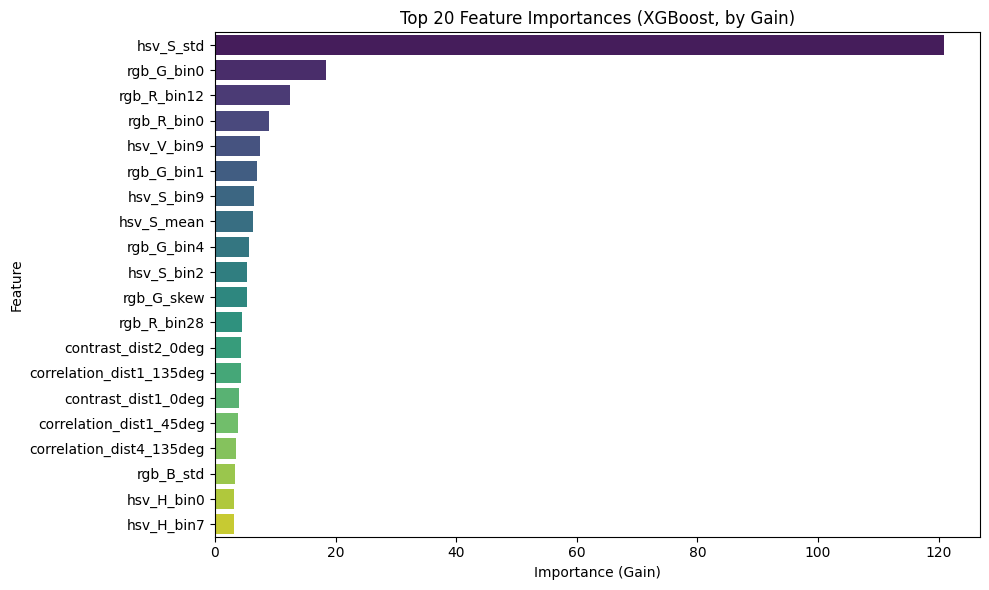

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=importance_df.head(20),
    palette="viridis"
)
plt.title("Top 20 Feature Importances (XGBoost, by Gain)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

                      Feature  Importance
206                 hsv_S_std    0.067351
161                hsv_V_bin0    0.059828
162                hsv_V_bin1    0.040526
33                 rgb_G_bin0    0.039667
159               hsv_S_bin30    0.039201
158               hsv_S_bin29    0.035697
34                 rgb_G_bin1    0.034623
156               hsv_S_bin27    0.034058
205                hsv_S_mean    0.030455
66                 rgb_B_bin1    0.029484
1                  rgb_R_bin0    0.028554
65                 rgb_B_bin0    0.027558
2                  rgb_R_bin1    0.023879
163                hsv_V_bin2    0.021543
160               hsv_S_bin31    0.021363
154               hsv_S_bin25    0.020214
3                  rgb_R_bin2    0.019960
35                 rgb_G_bin2    0.017204
157               hsv_S_bin28    0.017149
326  correlation_dist1_135deg    0.015232


C:\Users\adria\AppData\Local\Temp\ipykernel_4152\628532045.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


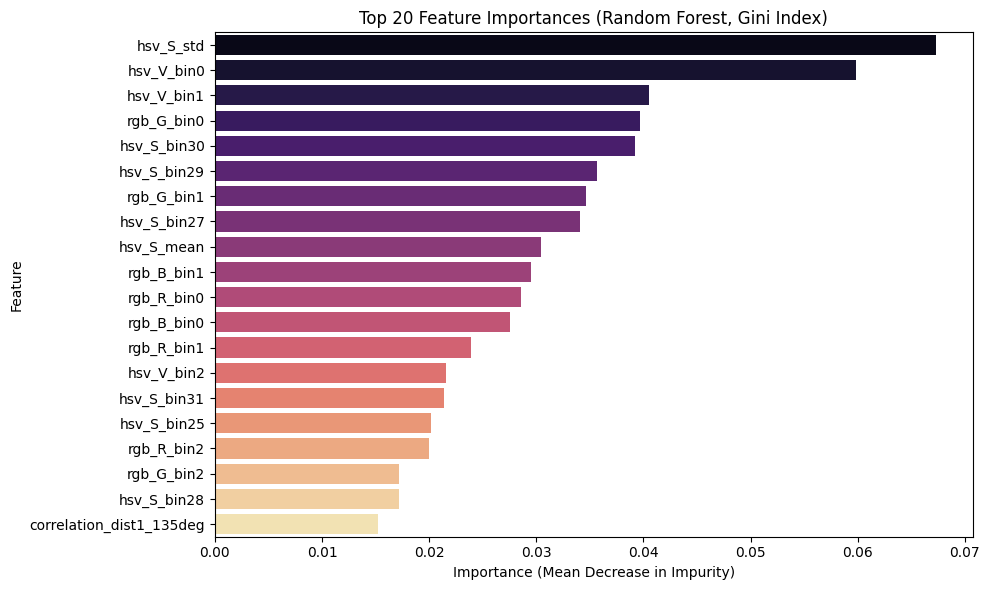

In [9]:
rf_importance = pd.DataFrame({
    'Feature': feature_names,   # same feature_names as before
    'Importance': rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance.head(20))

# Plot top 20
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(20),
    palette="magma"
)
plt.title("Top 20 Feature Importances (Random Forest, Gini Index)")
plt.xlabel("Importance (Mean Decrease in Impurity)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()